In [ ]:
!wget https://raw.githubusercontent.com/ye-kyaw-thu/sylbreak/master/python/sylbreak.py

--2025-12-24 15:53:31--  https://raw.githubusercontent.com/ye-kyaw-thu/sylbreak/master/python/sylbreak.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3668 (3.6K) [text/plain]
Saving to: ‘sylbreak.py’

sylbreak.py         100%[===================>]   3.58K  --.-KB/s    in 0s      

2025-12-24 15:53:31 (57.7 MB/s) - ‘sylbreak.py’ saved [3668/3668]



In [ ]:
!pip install 'datasets[audio]==2.14.4' 'fsspec==2023.9.2'

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.4/173.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
  Attempting uninstall: datasets
    Foun

In [ ]:
!pip install -q transformers datasets librosa evaluate jiwer gradio bitsandbytes accelerate
!pip install -q git+https://github.com/huggingface/peft.git@main

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 50.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install jiwer

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
speech_data = load_dataset("LULab/mediTalk-mm-rdy", split='test')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
from sylbreak import break_syllables, create_break_pattern

def syllable_break(text):
  """Syllable break for burmese texts"""
  text = text
  separator = ' '
  break_pattern = create_break_pattern()

  segmented = break_syllables(text, break_pattern, separator)
  return segmented

In [ ]:
def apply_syllable_break(text):
    text['prompt'] = syllable_break(text['prompt'])
    return text

dataset = speech_data.map(apply_syllable_break)
dataset

Map:   0%|          | 0/2920 [00:00<?, ? examples/s]

Dataset({
    features: ['speaker_id', 'prompt', 'audio'],
    num_rows: 2920
})

In [ ]:
speech_data = dataset.select(range(30))
speech_data

Dataset({
    features: ['speaker_id', 'prompt', 'audio'],
    num_rows: 30
})

In [ ]:
import numpy as np

def add_noise_snr(clean_audio, snr_db):
    """
    Add Gaussian noise to achieve target SNR (dB)
    """
    clean_audio = np.asarray(clean_audio, dtype=np.float32)

    signal_power = np.mean(clean_audio ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear

    noise = np.random.normal(0, np.sqrt(noise_power), clean_audio.shape)
    noisy_audio = clean_audio + noise

    return noisy_audio


In [ ]:
from transformers import (
    AutomaticSpeechRecognitionPipeline,
    WhisperForConditionalGeneration,
    WhisperTokenizer,
    WhisperProcessor,
)
from peft import PeftModel, PeftConfig


# peft_model_id = "Mike1794/LUlab_whisper-large-v3_preft_mm"
# peft_model_id = "Mike1794/LUlab_whisper-large_preft_mm"
peft_model_id = "YeBhoneLin10/whisper-small-peft-myanmar-v4"

language = "my"
task = "transcribe"
peft_config = PeftConfig.from_pretrained(peft_model_id)
model = WhisperForConditionalGeneration.from_pretrained(
    peft_config.base_model_name_or_path, load_in_8bit=True, device_map="auto"
)

model = PeftModel.from_pretrained(model, peft_model_id)
tokenizer = WhisperTokenizer.from_pretrained(peft_config.base_model_name_or_path, language=language, task=task)
processor = WhisperProcessor.from_pretrained(peft_config.base_model_name_or_path, language=language, task=task)
feature_extractor = processor.feature_extractor
forced_decoder_ids = processor.get_decoder_prompt_ids(language=language, task=task)
pipe = AutomaticSpeechRecognitionPipeline(model=model, tokenizer=tokenizer, feature_extractor=feature_extractor)

adapter_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
from tqdm import tqdm
import pandas as pd
import librosa
import json
from jiwer import wer

OUTPUT_JSON = "peft_small_whisper_snr_wer_results_peft.json"
snr_levels = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
results = []

for snr in snr_levels:
    print(f"\nEvaluating SNR = {snr} dB")

    for idx, item in enumerate(tqdm(speech_data)):
        audio = item["audio"]

        if isinstance(audio, dict):
            clean_audio = audio["array"]
            sr = audio["sampling_rate"]
        else:
            clean_audio = audio
            sr = 16000

        if sr != 16000:
            clean_audio = librosa.resample(clean_audio, orig_sr=sr, target_sr=16000)

        noisy_audio = add_noise_snr(clean_audio, snr)

        result = pipe({
            "array": noisy_audio,
            "sampling_rate": 16000
        },
            chunk_length_s=10,
            stride_length_s=2,
            generate_kwargs={"forced_decoder_ids": forced_decoder_ids})

        hypothesis = result["text"].strip()
        reference = item["prompt"].strip()

        error = wer(reference, hypothesis)

        wer_percent = error * 100
        wer_format = f"{wer_percent:.2f}"

        results.append({
            "utt_id": idx,
            "snr_db": snr,
            "reference": reference,
            "hypothesis": hypothesis,
            "wer": wer_format
        })



Evaluating SNR = -20 dB


  0%|          | 0/30 [00:00<?, ?it/s]Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
 33%|███▎      | 10/30 [02:06<03:08,  9.45s/it]Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To us


Evaluating SNR = -15 dB


100%|██████████| 30/30 [06:41<00:00, 13.39s/it]



Evaluating SNR = -10 dB


100%|██████████| 30/30 [08:54<00:00, 17.80s/it]



Evaluating SNR = -5 dB


100%|██████████| 30/30 [09:04<00:00, 18.15s/it]



Evaluating SNR = 0 dB


 33%|███▎      | 10/30 [03:17<06:10, 18.54s/it]Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


In [ ]:
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

In [ ]:
#import json
#import pandas as pd

#with open("/content/whisper_snr_wer_results_peft.json", "r", encoding="utf-8") as f:
#    data = json.load(f)

#df1 = pd.DataFrame(data)

In [ ]:
# df1["wer"] = df1["wer"].astype(float)

In [ ]:
# snr_summary1 = (
#    df1
#    .groupby("snr_db")
#    .agg(
#        avg_wer=("wer", "mean"),
#        std_wer=("wer", "std"),
#        num_utts=("wer", "count")
#    )
#    .reset_index()
#    .sort_values("snr_db")
#)

#print(snr_summary1)


   snr_db  avg_wer    std_wer  num_utts
0     -20   99.662   0.755791         5
1     -15   98.306   3.787899         5
2     -10   90.208  10.092639         5
3      -5   74.030  17.357092         5
4       0   59.200  24.761631         5
5       5   50.726  18.562977         5
6      10   43.474  21.944654         5
7      15   37.620  19.775599         5
8      20   35.866  20.245893         5


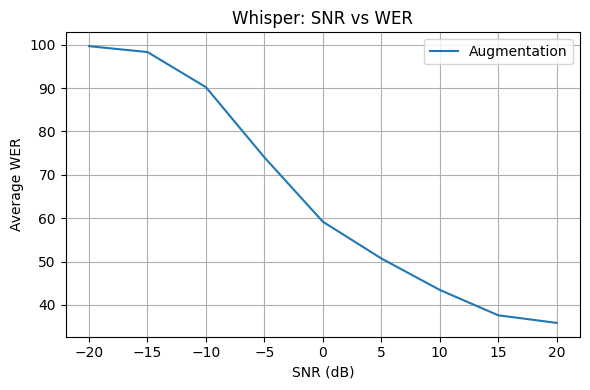

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 4))

# plt.errorbar(
#    snr_summary1["snr_db"],
#    snr_summary1["avg_wer"],
#    capsize=4,
#    label="Augmentation"
#)

#plt.xlabel("SNR (dB)")
#plt.ylabel("Average WER")
#plt.title("Whisper: SNR vs WER")
#plt.grid(True)
#plt.legend()
#plt.tight_layout()
#plt.show()
